In [2]:
import sys
import os
sys.path.append(os.getcwd())

from DATA.stock_invest_function import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine
from pykrx import stock
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

1#### 수출 데이터 및 경제지표를 가져와서 PCA를 만든다

In [3]:
# save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"
tic_name = 'A005930'
# hs_list = ['854232', '']

# 오늘 날짜 구하기 (YYYY-MM-DD)
today_date = pd.to_datetime(datetime.today().date())

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': 'hystox74.synology.me', # get_db_host(),     예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [4]:
# indicator = 'expDlr'
# hs_codes = ['854232', '852351']
#
# trade_list = []
#
# for code in hs_codes:
#     temp_df = load_forecast_by_hscode(db_info, code, table_name='korea_monthly_trade_data_forecast')
#     trade_list.append(temp_df)
#
#
# df = pd.concat(trade_list)
#
# # 피벗 테이블 생성
# pivot_df = df.pivot(index='date', columns='root_hs_code', values='final_expDlr_yoy')
#
# # 결측치 처리 (필요에 따라)
# # 결측치가 있는 행 제거
# pivot_df.dropna(inplace=True)
#
# # 데이터 표준화
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(pivot_df)
#
# # PCA 적용
# pca = PCA(n_components=1)  # 주성분 1개
# pca_data = pca.fit_transform(scaled_data)
#
# # 새로운 DataFrame 생성
# pca_df = pd.DataFrame(pca_data, index=pivot_df.index, columns=['principal component 1'])
#
# # 결과 출력
# print(pca_df.head())
#
#
# price_data = stock.get_market_ohlcv("20130101", "20250804", '005930')
# # 인덱스가 이미 날짜라 가정 (price_data.index가 '날짜')
# price_data.index = pd.to_datetime(price_data.index)
#
# # 1) 월말 종가
# df_monthly = price_data.resample('M').last()[['종가']]
#
# # 2) 1M/3M/6M 변화율 추가
# for m in [1, 3, 6]:
#     df_monthly[f'종가_변화율_{m}M'] = df_monthly['종가'].pct_change(periods=m)
#
# # (선택) 무한대/이상치 정리
# df_monthly = df_monthly.replace([float('inf'), float('-inf')], pd.NA)
#
# # 3) PCA와 결합 (PCA도 date를 인덱스로)
# pca_df.index = pd.to_datetime(pca_df.index)
# final_df = pd.concat([df_monthly, pca_df], axis=1)

# print(final_df.tail())
# kse_df = fetch_table_data(db_info, "KSE_Price")


✅ root_hs_code=854232에 해당하는 235개 행을 불러왔습니다.
✅ root_hs_code=852351에 해당하는 235개 행을 불러왔습니다.
            principal component 1
date                             
2008-01-31              -0.510962
2008-02-29              -0.367163
2008-03-31              -0.270196
2008-04-30              -0.324258
2008-05-31              -0.025881


In [28]:
fs_df = fetch_table_data(db_info, "korea_fs_data")
fs_df.rename(columns={'Date': 'date'}, inplace=True)
fs_df

✅ 'korea_fs_data' 테이블에서 5584577건의 데이터를 가져왔습니다.


,symbol,company_name,date,indicator,value
0,A000010,조흥은행,2004-01-31,수정PSR(연율화)(배),4.594400e-01
1,A000010,조흥은행,2004-02-29,수정PSR(연율화)(배),5.032000e-01
2,A000010,조흥은행,2004-03-31,계속사업이익(천원),3.612000e+07
3,A000010,조흥은행,2004-03-31,당기순이익(천원),3.612000e+07
4,A000010,조흥은행,2004-03-31,매출액(천원),7.920890e+08
...,...,...,...,...,...
5584572,A950220,네오이뮨텍,2025-03-31,총자산(천원),5.846556e+07
5584573,A950220,네오이뮨텍,2025-03-31,투자부동산(천원),0.000000e+00
5584574,A950220,네오이뮨텍,2025-04-30,수정PSR(연율화)(배),2.075926e+03
5584575,A950220,네오이뮨텍,2025-05-31,수정PSR(연율화)(배),2.851852e+03


In [56]:
target_company = fs_df[fs_df['symbol'] == 'A058470']
target_company

,symbol,company_name,date,indicator,value
3234176,A058470,리노공업,2004-01-31,수정PSR(연율화)(배),2.436860e+00
3234177,A058470,리노공업,2004-02-29,수정PSR(연율화)(배),2.170720e+00
3234178,A058470,리노공업,2004-03-31,계속사업이익(천원),1.965206e+06
3234179,A058470,리노공업,2004-03-31,당기순이익(천원),1.965206e+06
3234180,A058470,리노공업,2004-03-31,당좌자산(천원),2.152894e+07
...,...,...,...,...,...
3236884,A058470,리노공업,2025-03-31,총자산(천원),6.968875e+08
3236885,A058470,리노공업,2025-03-31,투자부동산(천원),0.000000e+00
3236886,A058470,리노공업,2025-04-30,수정PSR(연율화)(배),8.771970e+00
3236887,A058470,리노공업,2025-05-31,수정PSR(연율화)(배),9.622440e+00


In [57]:
# 피벗 테이블 생성
pivot_df = target_company.pivot_table(
    index='date',
    columns='indicator',
    values='value'
)

# 인덱스를 날짜형으로 변환 후 정렬
pivot_df.index = pd.to_datetime(pivot_df.index)
pivot_df = pivot_df.sort_index()

pivot_df.columns.tolist()

['YoY_계속사업이익',
 'YoY_당기순이익',
 'YoY_매출액',
 'YoY_매출총이익',
 'YoY_영업이익',
 '계속사업이익(천원)',
 '당기순이익(천원)',
 '당좌자산(천원)',
 '매출액(천원)',
 '매출채권및기타채권(천원)',
 '매출총이익(천원)',
 '매출총이익률',
 '배당금지급(영업,투자,재무)(천원)',
 '비유동부채(천원)',
 '비유동부채비율',
 '수정PSR(연율화)(배)',
 '순이익률',
 '연구개발비(천원)',
 '영업이익(천원)',
 '영업이익률',
 '영업활동으로인한현금흐름(직전4분기)(천원)',
 '영업활동으로인한현금흐름(천원)',
 '영업활동으로인한현금흐름(평균)(천원)',
 '유동자산(천원)',
 '유형자산감가상각비(천원)',
 '재고자산(천원)',
 '지배주주지분(천원)',
 '지배주주총포괄이익(천원)',
 '총자본(천원)',
 '총자산(천원)',
 '투자부동산(천원)']

In [58]:
pivot_df = pivot_df.dropna()

In [61]:
# 0. 시계열 정렬
pivot_df = pivot_df.sort_index()

# 1. 최근 4분기 영업이익 합산 (rolling sum)
pivot_df['영업이익_최근4분기(천원)'] = pivot_df['영업이익(천원)'].rolling(window=4, min_periods=4).sum()

# 2. NOPAT 계산
tax_rate = 0.25
pivot_df['NOPAT'] = pivot_df['영업이익_최근4분기(천원)'] * (1 - tax_rate)

# 3. 투하자본 계산 (현금 차감 버전 예시)
# '현금및현금성자산(천원)' 칼럼이 있다면 차감
pivot_df['투하자본(천원)'] = (
    pivot_df['총자본(천원)'] +
    pivot_df['비유동부채(천원)'] -
    pivot_df.get('현금및현금성자산(천원)', 0)  # 없으면 0 처리
)

# 4. ROIC 계산
pivot_df['ROIC'] = pivot_df['NOPAT'] / pivot_df['투하자본(천원)']

# 확인
print(pivot_df[['영업이익(천원)', '영업이익_최근4분기(천원)', 'NOPAT', '투하자본(천원)', 'ROIC']].head(10))

indicator    영업이익(천원)  영업이익_최근4분기(천원)        NOPAT    투하자본(천원)      ROIC
date                                                                    
2005-03-31  2679965.0             NaN          NaN  38068536.0       NaN
2005-06-30  4042337.0             NaN          NaN  41364748.0       NaN
2005-09-30  3805482.0             NaN          NaN  44707954.0       NaN
2005-12-31  3823110.0      14350894.0  10763170.50  47905700.0  0.224674
2006-03-31  3909613.0      15580542.0  11685406.50  46927250.0  0.249011
2006-06-30  3792700.0      15330905.0  11498178.75  50084206.0  0.229577
2006-09-30  4744476.0      16269899.0  12202424.25  53955673.0  0.226156
2006-12-31  3219350.0      15666139.0  11749604.25  56815892.0  0.206801
2007-03-31  3363112.0      15119638.0  11339728.50  55187252.0  0.205477
2007-06-30  3476409.0      14803347.0  11102510.25  55795422.0  0.198986


In [64]:
price_data = stock.get_market_ohlcv("20130101", "20250804", '005930')

In [65]:
price_data

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2013-05-24,29740,29880,29440,29720,203812,NaN
2013-05-27,29800,29980,29740,29780,122928,0.201884
2013-05-28,29620,29920,29620,29680,231761,-0.335796
2013-05-29,29680,30459,29660,30240,295211,1.886792
2013-05-30,30360,30980,30239,30880,455560,2.116402
...,...,...,...,...,...,...
2025-07-29,70800,70800,68800,70600,28190940,0.284091
2025-07-30,71000,73700,70600,72600,34761444,2.832861
2025-07-31,73000,74000,71000,71400,26568072,-1.652893


In [69]:
import yfinance as yf

# 코스피 지수 티커
kospi = yf.download("^KS11", start="2013-01-01", end="2025-08-04", interval="1d")

# 데이터 확인
print(kospi.head())

# 종가만 사용하고 싶다면
kospi_close = kospi['Close']
print(kospi_close.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open  Volume
Ticker            ^KS11        ^KS11        ^KS11        ^KS11   ^KS11
Date                                                                  
2013-01-02  2031.099976  2033.660034  2012.300049  2013.739990  364100
2013-01-03  2019.410034  2042.479980  2018.489990  2041.239990  491000
2013-01-04  2011.939941  2018.630005  2001.530029  2017.880005  378900
2013-01-07  2011.250000  2014.000000  1996.469971  2012.150024  536200
2013-01-08  1997.939941  2009.989990  1997.910034  2003.219971  493700
Ticker            ^KS11
Date                   
2013-01-02  2031.099976
2013-01-03  2019.410034
2013-01-04  2011.939941
2013-01-07  2011.250000
2013-01-08  1997.939941


In [68]:
! pip install yfinance


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     -------------------------------------- 949.2/949.2 kB 8.8 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 9.6 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=ed22eec153508e793f1ddfe3d60db2297ff5f1d7df19bebcb69f1ff652839251
  Stored in directory: c:\users\metam\appdata\local\pip\cache\wheels\98\75\bc\9eaa3cdeaaca347bab26c7e83a7e2

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='date'>

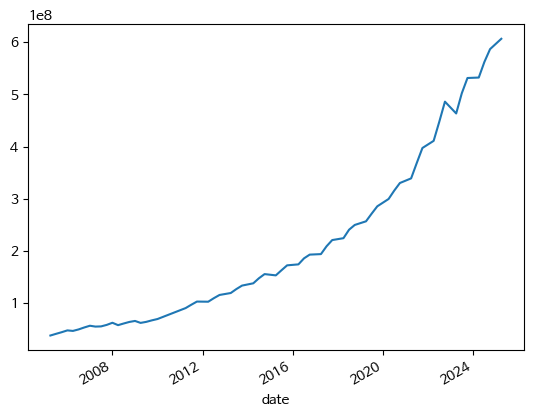

In [63]:
pivot_df['총자본(천원)'].plot()

In [44]:
pivot_df

indicator,YoY_계속사업이익,YoY_당기순이익,YoY_매출액,YoY_매출총이익,YoY_영업이익,계속사업이익(천원),당기순이익(천원),당좌자산(천원),매출액(천원),매출채권및기타채권(천원),...,유형자산감가상각비(천원),재고자산(천원),지배주주지분(천원),지배주주총포괄이익(천원),총자본(천원),총자산(천원),투자부동산(천원),NOPAT,투하자본(천원),ROIC
date,,,,,,,,,,,,,,,,,,,,,
2004-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-02-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-31,NaN,NaN,NaN,NaN,NaN,3.510866e+08,3.510866e+08,1.103725e+09,1.296647e+09,6.996277e+08,...,10168755.0,3.916278e+08,3.076261e+09,2.917977e+08,3.076261e+09,7.253612e+09,0.0,2.183894e+08,5.829267e+09,0.037464
2004-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-31,3.229541,3.229541,0.419124,1.106932,1.578111,8.108195e+09,8.108195e+09,2.667684e+10,1.763914e+10,1.079922e+10,...,75503000.0,1.455135e+10,8.142401e+10,8.114054e+09,8.143875e+10,1.239855e+11,197000.0,5.580378e+09,9.914907e+10,0.056283
2025-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
